# HW 16 - Animation
ULAB - Physics and Astronomy Division \
Due **Sunday, March 16th, 2025 at 11:59pm** on Gradescope

**Make sure to work on this notebook in DataHub!**

# 1) Recap of lecture
**Copy and paste** your code from lecture for the neural network with the **default** settings (i.e. before we improved the model). Make sure to also import the `data.py` file. 

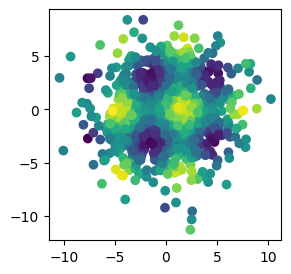

Iteration 0, Loss: 1.0757758617401123
Iteration 100, Loss: 0.958625316619873
Iteration 200, Loss: 0.9138311743736267
Iteration 300, Loss: 0.8251482248306274
Iteration 400, Loss: 0.6963152885437012
Iteration 500, Loss: 0.5688156485557556
Iteration 600, Loss: 0.4749316871166229
Iteration 700, Loss: 0.41401562094688416
Iteration 800, Loss: 0.3744092285633087
Iteration 900, Loss: 0.3433557450771332


C:\Users\kaash_rosqmgh\AppData\Local\Programs\Python\Python310\lib\site-packages\torch\functional.py:539: UserWarning: torch.meshgrid: in an upcoming release, it will be required to pass the indexing argument. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\aten\src\ATen\native\TensorShape.cpp:3638.)
  return _VF.meshgrid(tensors, **kwargs)  # type: ignore[attr-defined]


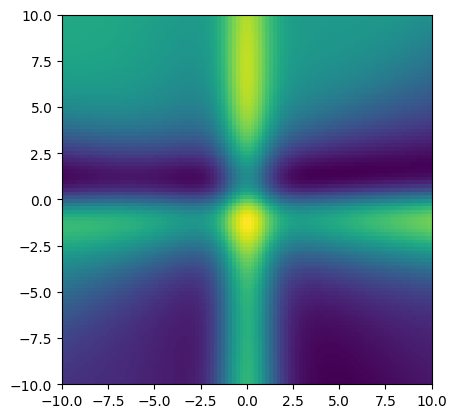

In [1]:
# Your code here
import torch
import numpy as np

# Underlying Pattern we are trying to find 
x_data = np.linspace(-3 * np.pi, 3 * np.pi, 1000)
y_data = np.linspace(-3 * np.pi, 3 * np.pi, 1000)
X, Y = np.meshgrid(x_data, y_data)

pattern = np.sin(X) + np.cos(Y)

# Actual data that we will be using
# Defining the dataset dimensions
N, D_in, H, D_out = 1000, 2, 50, 1

# Creating the input data
x = torch.randn(N, D_in) * 3.1415
y = (x[:, 0].sin() + x[:, 1].cos()).unsqueeze(1)

noise = torch.randn(N, D_out) * 0.1
y += noise

x_values = x.numpy()[:, 0]
y_values = x.numpy()[:, 1]
color_values = y.numpy().flatten()

import data
import matplotlib.pyplot as plt
plt.figure(figsize=(3,3))
plt.scatter(data.x_values, data.y_values, c=data.color_values)
plt.show()
#2. build model
model = torch.nn.Sequential(
    torch.nn.Linear(2, 50),  #input x,y=2
    torch.nn.Sigmoid(),
    torch.nn.Linear(50, 1))   #output z=1
#3. train model
#loss function (how wrong model is), optimizer (how much to change before trying again)
loss_fn = torch.nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
#training loop, model improves each time
for t in range(1000):
    y_pred = model(data.x)
    loss = loss_fn(y_pred, data.y)
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    if t % 100 == 0:
        print(f"Iteration {t}, Loss: {loss.item()}")

#4. evaluate model
new_x = torch.linspace(-10,10,100)
grid = torch.stack(torch.meshgrid((new_x, new_x)), dim=2)
output = model(grid).detach()
plt.imshow(output, extent=(-10,10,-10,10))
plt.show()

What is the difference between artificial intelligence, machine learning and deep learning?

In [ ]:
# Your comment here 
#AI is broad concept encompassing machines mimicking intelligence, machine learning enables machines to get patterns from data, and deep learning uses neural networks to model complex patterns.

What is a neural network?

In [4]:
# Your comment here
#neural network is a type of ML inspired by the human brain that learns patterns to make decisions and predictions

In lecture, we used `torch.nn.Linear(2, 50)`. What do the numbers `2` and `50` represent? 

In [2]:
# Your comment here
#2 is the number of inputs, and 50 is the number of outputs

What does the activation function do?

In [3]:
# Your comment here
#introduces nonlinearity to yield complex patterns

What is a loss function? Why do we need one?

In [5]:
# Your comment here
#measures how far predictions are from target or expected, helps us measure how effective model is

Why do we call `optimizer.zero_grad()` before calling `loss.backward()`?

In [6]:
# Your comment here
#it clears the gradients from the previous iterations to avoid accumulation

# 2) Modifying the Neural Network
What line do you need to modify to use **30 neurons** instead of **50**? Don't change anything else. Give the original and then modified line. 

In [7]:
# Your code here
#og
model = torch.nn.Sequential(
    torch.nn.Linear(2, 50), 
    torch.nn.Sigmoid(),
    torch.nn.Linear(50, 1)  
)
#new
model = torch.nn.Sequential(
    torch.nn.Linear(2, 30), 
    torch.nn.Sigmoid(),
    torch.nn.Linear(30, 1)  
)

With your default code above, run your model with **30 neurons**. Compare the loss functions from lecture to your modification on the **1000th** iteration. 

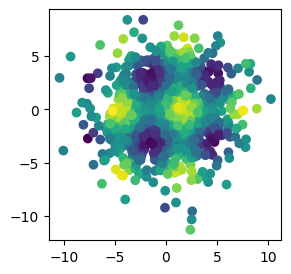

Iteration 0, Loss: 1.534849762916565
Iteration 100, Loss: 0.9658427238464355
Iteration 200, Loss: 0.9472113251686096
Iteration 300, Loss: 0.921786367893219
Iteration 400, Loss: 0.8872839212417603
Iteration 500, Loss: 0.8419575095176697
Iteration 600, Loss: 0.7858588099479675
Iteration 700, Loss: 0.7221243977546692
Iteration 800, Loss: 0.6553080081939697
Iteration 900, Loss: 0.5902637839317322


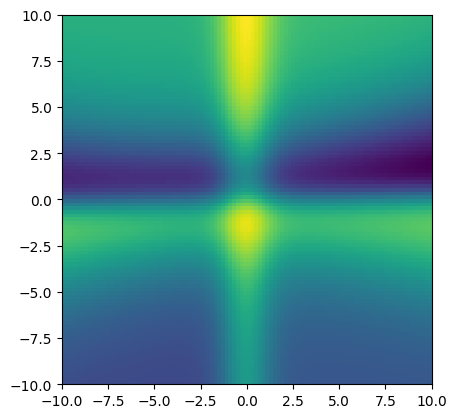

In [8]:
# Your comment here
plt.figure(figsize=(3,3))
plt.scatter(data.x_values, data.y_values, c=data.color_values)
plt.show()
#2. build model
model = torch.nn.Sequential(
    torch.nn.Linear(2, 30),  #input x,y=2
    torch.nn.Sigmoid(),
    torch.nn.Linear(30, 1))   #output z=1
#3. train model
#loss function (how wrong model is), optimizer (how much to change before trying again)
loss_fn = torch.nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
#training loop, model improves each time
for t in range(1000):
    y_pred = model(data.x)
    loss = loss_fn(y_pred, data.y)
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    if t % 100 == 0:
        print(f"Iteration {t}, Loss: {loss.item()}")

#4. evaluate model
new_x = torch.linspace(-10,10,100)
grid = torch.stack(torch.meshgrid((new_x, new_x)), dim=2)
output = model(grid).detach()
plt.imshow(output, extent=(-10,10,-10,10))
plt.show()

In [9]:
#since in lecture, we printed up to the 900th iteration in the default code, that is what I will compare to. With 30 neurons, the loss function is greater at the 900th iteration, which means it is less precise, as expected.

Return to **50 neurons**. Change your activation function from `torch.nn.Sigmoid()` to `torch.nn.ReLU`. Compare the loss functions from lecture to your modification on the **1000th** iteration. 

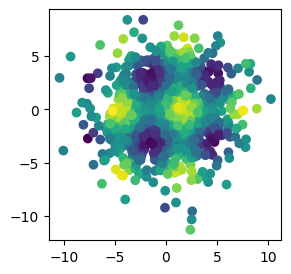

Iteration 0, Loss: 1.8431414365768433
Iteration 100, Loss: 0.9055244326591492
Iteration 200, Loss: 0.8469545245170593
Iteration 300, Loss: 0.7627115249633789
Iteration 400, Loss: 0.6579964756965637
Iteration 500, Loss: 0.5498852729797363
Iteration 600, Loss: 0.462404727935791
Iteration 700, Loss: 0.39358967542648315
Iteration 800, Loss: 0.3469078242778778
Iteration 900, Loss: 0.3147841989994049


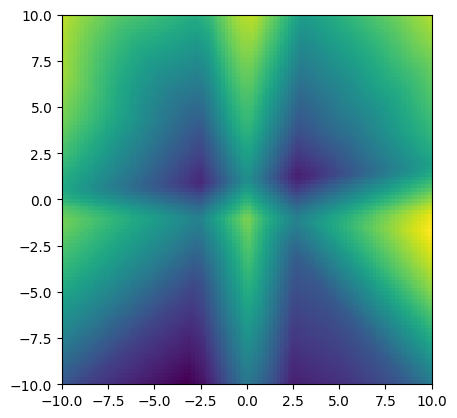

In [10]:
# Your comment here
plt.figure(figsize=(3,3))
plt.scatter(data.x_values, data.y_values, c=data.color_values)
plt.show()
#2. build model
model = torch.nn.Sequential(
    torch.nn.Linear(2, 50),  #input x,y=2
    torch.nn.ReLU(),
    torch.nn.Linear(50, 1))   #output z=1
#3. train model
#loss function (how wrong model is), optimizer (how much to change before trying again)
loss_fn = torch.nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
#training loop, model improves each time
for t in range(1000):
    y_pred = model(data.x)
    loss = loss_fn(y_pred, data.y)
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    if t % 100 == 0:
        print(f"Iteration {t}, Loss: {loss.item()}")

#4. evaluate model
new_x = torch.linspace(-10,10,100)
grid = torch.stack(torch.meshgrid((new_x, new_x)), dim=2)
output = model(grid).detach()
plt.imshow(output, extent=(-10,10,-10,10))
plt.show()

In [11]:
#lecture: 0.34 vs. ReLU: 0.31, ReLU seems to be a bit better but not significantly

Change your activation function from `torch.nn.Sigmoid()` to `torch.nn.Tanh`? Compare the loss functions from lecture to your modification on the **1000th** iteration. 

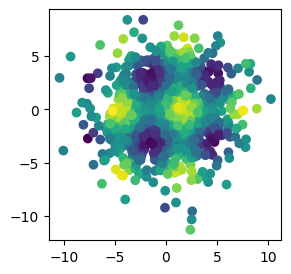

Iteration 0, Loss: 1.1616270542144775
Iteration 100, Loss: 0.8055471181869507
Iteration 200, Loss: 0.5660023093223572
Iteration 300, Loss: 0.3811616599559784
Iteration 400, Loss: 0.3005305826663971
Iteration 500, Loss: 0.25122788548469543
Iteration 600, Loss: 0.21753013134002686
Iteration 700, Loss: 0.19237716495990753
Iteration 800, Loss: 0.17138707637786865
Iteration 900, Loss: 0.15320338308811188


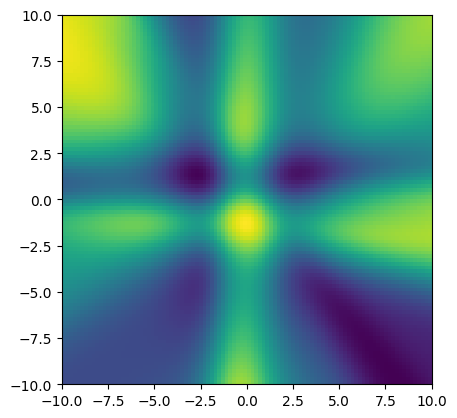

In [12]:
# Your comment here
plt.figure(figsize=(3,3))
plt.scatter(data.x_values, data.y_values, c=data.color_values)
plt.show()
#2. build model
model = torch.nn.Sequential(
    torch.nn.Linear(2, 50),  #input x,y=2
    torch.nn.Tanh(),
    torch.nn.Linear(50, 1))   #output z=1
#3. train model
#loss function (how wrong model is), optimizer (how much to change before trying again)
loss_fn = torch.nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
#training loop, model improves each time
for t in range(1000):
    y_pred = model(data.x)
    loss = loss_fn(y_pred, data.y)
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    if t % 100 == 0:
        print(f"Iteration {t}, Loss: {loss.item()}")

#4. evaluate model
new_x = torch.linspace(-10,10,100)
grid = torch.stack(torch.meshgrid((new_x, new_x)), dim=2)
output = model(grid).detach()
plt.imshow(output, extent=(-10,10,-10,10))
plt.show()

In [13]:
#Tanh is 0.15, much better than 0.34

What is the difference between `torch.nn.Sigmoid()`, `torch.nn.ReLU` and `torch.nn.Tanh`? 

In [14]:
# Your comment here 
#they are all effective in different situations. ReLU is general purpose, sigmoid is good for binary data sets, and tanh is useful when the data is centered around 0.

Return to `torch.nn.Sigmoid()`. Change your learning rate from `1e-3` to `1e-2` in your optimizer. Compare the loss functions from lecture to your modification on the **1000th** iteration. 

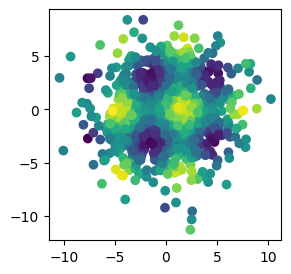

Iteration 0, Loss: 1.0773650407791138
Iteration 100, Loss: 0.40930184721946716
Iteration 200, Loss: 0.25550562143325806
Iteration 300, Loss: 0.17154785990715027
Iteration 400, Loss: 0.11320707947015762
Iteration 500, Loss: 0.08908485621213913
Iteration 600, Loss: 0.06807032227516174
Iteration 700, Loss: 0.05067116394639015
Iteration 800, Loss: 0.03784599527716637
Iteration 900, Loss: 0.03172906115651131


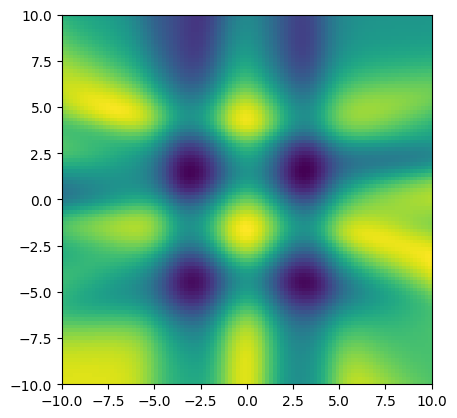

In [15]:
# Your comment here
plt.figure(figsize=(3,3))
plt.scatter(data.x_values, data.y_values, c=data.color_values)
plt.show()
#2. build model
model = torch.nn.Sequential(
    torch.nn.Linear(2, 50),  #input x,y=2
    torch.nn.Sigmoid(),
    torch.nn.Linear(50, 1))   #output z=1
#3. train model
#loss function (how wrong model is), optimizer (how much to change before trying again)
loss_fn = torch.nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-2)
#training loop, model improves each time
for t in range(1000):
    y_pred = model(data.x)
    loss = loss_fn(y_pred, data.y)
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    if t % 100 == 0:
        print(f"Iteration {t}, Loss: {loss.item()}")

#4. evaluate model
new_x = torch.linspace(-10,10,100)
grid = torch.stack(torch.meshgrid((new_x, new_x)), dim=2)
output = model(grid).detach()
plt.imshow(output, extent=(-10,10,-10,10))
plt.show()

In [16]:
#with higher learning rate, loss drops to 0.03 and the pattern resembles the hidden pattern a lot more

Modify your model to have **two hidden layers** instead of one. Give that code here.

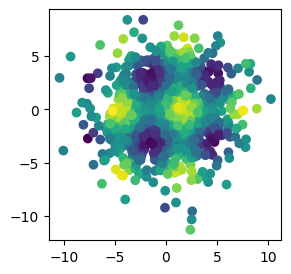

Iteration 0, Loss: 1.1225082874298096
Iteration 100, Loss: 0.3248756229877472
Iteration 200, Loss: 0.17147336900234222
Iteration 300, Loss: 0.12349724024534225
Iteration 400, Loss: 0.10403881967067719
Iteration 500, Loss: 0.08420226722955704
Iteration 600, Loss: 0.06745977699756622
Iteration 700, Loss: 0.05371112748980522
Iteration 800, Loss: 0.0590643547475338
Iteration 900, Loss: 0.042052146047353745


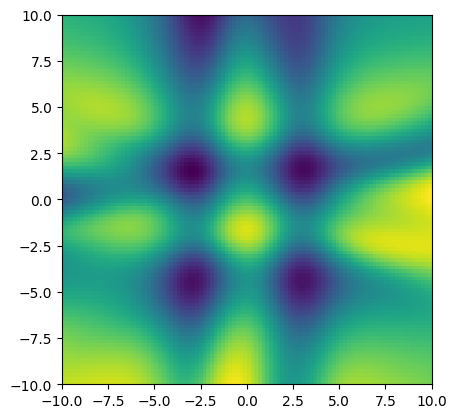

In [17]:
# Your code here
plt.figure(figsize=(3,3))
plt.scatter(data.x_values, data.y_values, c=data.color_values)
plt.show()
#2. build model
model = torch.nn.Sequential(
    torch.nn.Linear(2, 50),  #input x,y=2
    torch.nn.Sigmoid(),
    torch.nn.Linear(50, 30),
    torch.nn.Sigmoid(),
    torch.nn.Linear(30, 1))   #output z=1
#3. train model
#loss function (how wrong model is), optimizer (how much to change before trying again)
loss_fn = torch.nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-2)
#training loop, model improves each time
for t in range(1000):
    y_pred = model(data.x)
    loss = loss_fn(y_pred, data.y)
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    if t % 100 == 0:
        print(f"Iteration {t}, Loss: {loss.item()}")

#4. evaluate model
new_x = torch.linspace(-10,10,100)
grid = torch.stack(torch.meshgrid((new_x, new_x)), dim=2)
output = model(grid).detach()
plt.imshow(output, extent=(-10,10,-10,10))
plt.show()

# 3) More Advanced
Create a new file called `new_data.py`, make a new "hidden" function and add noise/ obscure the data (e.g. like what is done in `data.py` from lecture). Import that file here.

In [18]:
# Your code here
import new_data

Define a new model and train it **poorly** in the cell below.

In [19]:
# Your code here
poor_model = torch.nn.Sequential(
    torch.nn.Linear(2, 10), 
    torch.nn.ReLU(),
    torch.nn.Linear(10, 1)
)

loss_fn = torch.nn.MSELoss()
optimizer = torch.optim.SGD(poor_model.parameters(), lr=0.01)

for t in range(10): #few iterations
    y_pred = poor_model(x)
    loss = loss_fn(y_pred, y)
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    print(f"Iteration {t}, Loss: {loss.item()}")


Iteration 0, Loss: 3.1760849952697754
Iteration 1, Loss: 2.3334028720855713
Iteration 2, Loss: 1.8420573472976685
Iteration 3, Loss: 1.541488528251648
Iteration 4, Loss: 1.3520240783691406
Iteration 5, Loss: 1.2301698923110962
Iteration 6, Loss: 1.150627851486206
Iteration 7, Loss: 1.0980746746063232
Iteration 8, Loss: 1.062939167022705
Iteration 9, Loss: 1.0391424894332886


Improve your model and train it **well** in the cell below. (You can add more neurons, iterations, etc).

In [20]:
improved_model = torch.nn.Sequential(
    torch.nn.Linear(2, 100), 
    torch.nn.ReLU(),
    torch.nn.Linear(100, 1)
)

loss_fn = torch.nn.MSELoss()
optimizer = torch.optim.SGD(improved_model.parameters(), lr=0.01)

for t in range(1000):
    y_pred = improved_model(x)
    loss = loss_fn(y_pred, y)
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    if t % 100 == 0:
        print(f"Iteration {t}, Loss: {loss.item()}")


Iteration 0, Loss: 1.119360327720642
Iteration 100, Loss: 0.7628570199012756
Iteration 200, Loss: 0.6610776782035828
Iteration 300, Loss: 0.5954121351242065
Iteration 400, Loss: 0.5499434471130371
Iteration 500, Loss: 0.5155415534973145
Iteration 600, Loss: 0.48695507645606995
Iteration 700, Loss: 0.46181362867355347
Iteration 800, Loss: 0.439245343208313
Iteration 900, Loss: 0.41878724098205566


Make foure subplots (two rows, two columns). 
- (TOP LEFT) Show what the "hidden pattern" is supposed to be.
- (TOP RIGHT) Show that your "data" is.
- (BOTTOM LEFT) Show your model's prediction when you trained it poorly.
- (BOTTOM RIGHT) Show your model's prediction when you trained it well.

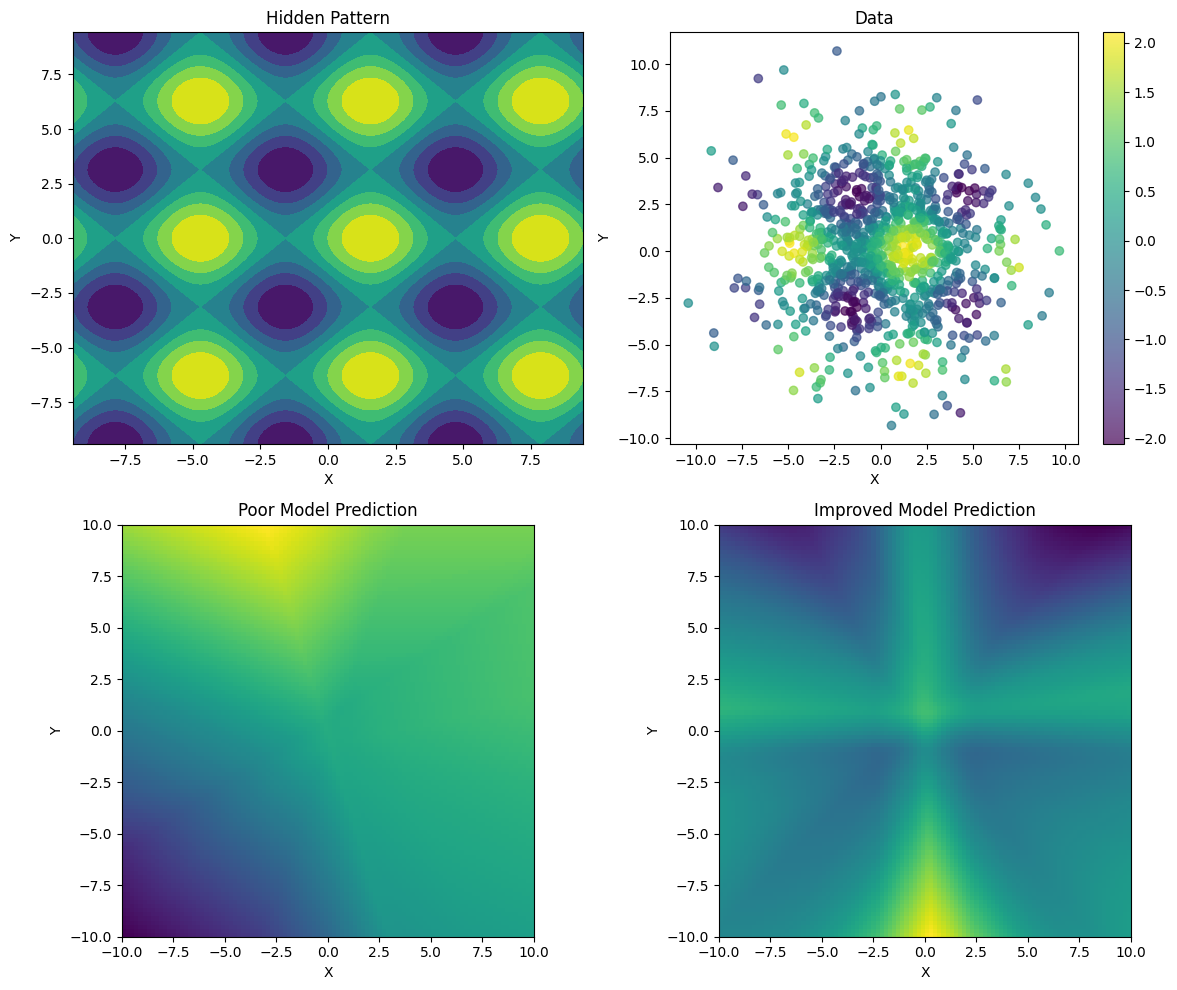

In [23]:
# Your code here

# Generate predictions over a new grid for visualization
new_x = torch.linspace(-10, 10, 100)
grid = torch.stack(torch.meshgrid((new_x, new_x)), dim=2)  # Create a meshgrid of inputs

# Poor model prediction
poor_model_output = poor_model(grid.view(-1, 2)).detach().numpy().reshape(100, 100)

# Improved model prediction
improved_model_output = improved_model(grid.view(-1, 2)).detach().numpy().reshape(100, 100)

# Create subplots
fig, axs = plt.subplots(2, 2, figsize=(12, 10))

#hidden pattern (TOP LEFT)
axs[0, 0].contourf(X, Y, pattern, cmap='viridis')
axs[0, 0].set_title("Hidden Pattern")
axs[0, 0].set_xlabel('X')
axs[0, 0].set_ylabel('Y')

#noisy data (TOP RIGHT)
scatter = axs[0, 1].scatter(x.numpy()[:, 0], x.numpy()[:, 1], c=y.numpy().flatten(), cmap='viridis', alpha=0.7)
axs[0, 1].set_title("Data")
axs[0, 1].set_xlabel('X')
axs[0, 1].set_ylabel('Y')
fig.colorbar(scatter, ax=axs[0, 1])

#plot the poor model's prediction (BOTTOM LEFT)
axs[1, 0].imshow(poor_model_output, extent=(-10, 10, -10, 10), origin='lower', cmap='viridis')
axs[1, 0].set_title("Poor Model Prediction")
axs[1, 0].set_xlabel('X')
axs[1, 0].set_ylabel('Y')

#plot the improved model's prediction (BOTTOM RIGHT)
axs[1, 1].imshow(improved_model_output, extent=(-10, 10, -10, 10), origin='lower', cmap='viridis')
axs[1, 1].set_title("Improved Model Prediction")
axs[1, 1].set_xlabel('X')
axs[1, 1].set_ylabel('Y')

plt.tight_layout()
plt.show()

# 4) Challenge
Find some data online and build a neural network around it. Make sure to also answer these questions:
- Where did you find your data? 
- How well does your model match your data?

In [ ]:
# Your code here

Once you are done, make sure to:
- Download this notebook and all releveant files (`new_data.py`, stuff from question 4, etc) from datahub.
- Move it to your **remote repository**.
- Upload to Gradescope!